In [124]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import csv
from scipy import stats

# constants
g = 1.62 # m/s/s acceleration due to gravity on the moon
k = 5 # falls between .0045 and .0055 depending on crater material and explosive type & placement
z = 2.7071 # this value of z conserves vertical momentum. in practice, z falls between 2 and 4   
v = 10000 # 10 km/s velocity
density = .00325 # projectile density in kg/cm^3
s_density = .00271 # surface density of anorthosite in kg/cm^3
theta = 45

# display constants 
print("")
print("\033[1mConstants \033[0m")
print(f"""g = {g}m/s/s
k = {k}
z = {z}
velocity = {v} m/s
density = {density} kg/cm^3""")


Constants 
g = 1.62m/s/s
k = 5
z = 2.7071
velocity = 10000 m/s
density = 0.00325 kg/cm^3


In [143]:
# transient crater -- both simple and complex craters

# transient crater diameter
# Melosh eq. 6.12
def iradius_to_tdiam(dp, ds, ir, v, g, theta): # projectile density, surface density, impact radius, impact velocity, gravity, impact angle
    # takes units (any, any, km, m/s, m/s/s, none)
    irad = ir*1000 # km to m
    td = 1.161 * ((dp/ds)**(1/3)) * ((2*irad)**0.78) * (v**0.44) * (g**(-0.22)) * ((math.sin(math.radians(theta)))**(1/3))
    return td/1000 # m to km

print(iradius_to_tdiam(0.125, 0.00325, 1.62, 10000, 0.00271, 45))
print(0.823 * (iradius_to_tdiam(.003250, .002710, 0.5, 10000, 1.62, 45)**1.13))

403.6218188171608
14.210361564099152


In [126]:
# simple craters

# calculate final crater radius given impactor radius
# Maxwell eq 12
def simple_cradius(r, d, g, k, z, v): # impactor radius, density, gravity, k constant, z constant, velocity
    # d in kg/cm^3; r in km; g in m/s/s; v in m/s
    r_cm = r * 100000 # put radius in cm
    mass = (4/3)*(math.pi)*(r_cm**3)*d
    ke = (1/2)*mass*(v**2) # kinetic energy
    return (k*(4*z*(z - 2)*((ke*2.39006e-10)**(2*z/3))/g)**(1/(2*z + 1)))/1000 # crater radius

# Melosh p. 224 simple craters " its rim-to-floor depth is about 1/5 of its rim-to-rim diameter"
def simple_depth(ir, d, g, k, z, v): 
    diameter = 2*simple_cradius(ir, d, g, k, z, v) # crater diameter
    return 1/5 * crad

# Melosh p. 242 from Maxwell streamline equation. Uses transient crater radius
def simple_hexc(ir, d, g, k, z, v):
    crad = (1/2)*iradius_to_tdiam(ir, d, g, k, z, v) # crater radius
    return crad*(z - 2)*((z - 1)**((1 - z)/(z - 2)))

In [148]:
# complex craters

# calculate final crater radius given impactor radius
def complex_cdiam(ir, dp, g, v, ds, theta): # impactor radius, density, gravity, k constant, z constant, velocity
    # takes units (km, kg/cm3, m/s/s, none, none, m/s)
    td = iradius_to_tdiam(dp, ds, ir, v, g, theta) # transient crater radius in km
    return 0.823 * (td**1.13) # returns final crater diameter in km Melosh eq. 6.2

# calculate final crater depth given final crater radius
def complex_depth(cdiam):
    return 0.01 * cdiam

# calculate max excavation crater depth given final crater diameter
def complex_hexc(cdiam):
    return 0.075 * cdiam

In [149]:
# simulation data
sim_r = [0.125, 0.5, 2.5, 5, 10]
sim_h = [1.3, 3.25, 5.5, 8.5, 8.5]

# sample impactor radii in km
iradii = np.arange(0.125, 2, 0.125)

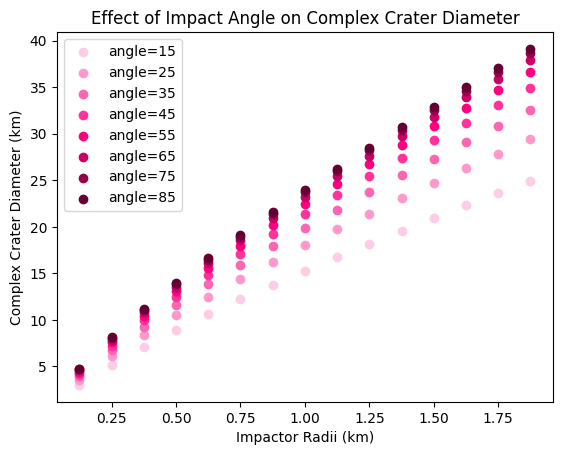

In [150]:
# complex crater diameters based on impact angle

angles = np.arange(15, 90, 10)
colors = [[(255/255, 204/255, 229/255)], [(255/255, 153/255, 204/255)], [(255/255, 102/255, 178/255)], [(255/255, 51/255, 153/255)], [(255/255, 0, 127/255)], [(204/255, 0, 102/255)], [(153/255, 0, 76/255)], [(102/255, 0, 51/255)]]
count = 0
for a in angles:
    # create complex crater diameters list
    diams = []
    for r in iradii:
        diams.append(iradius_to_tdiam(density, s_density, r, v, g, a))
    plt.scatter(iradii, diams, c=colors[count], label=f"angle={a}")
    count += 1
plt.xlabel("Impactor Radii (km)")
plt.ylabel("Complex Crater Diameter (km)")
plt.title("Effect of Impact Angle on Complex Crater Diameter")
plt.legend()
plt.show()

0.125 0.00325 1.62 10000 0.00271 45
4.187448238988361
0.25 0.00325 1.62 10000 0.00271 45
7.713958355278753
0.375 0.00325 1.62 10000 0.00271 45
11.027679247639076
0.5 0.00325 1.62 10000 0.00271 45
14.210361564099152
0.625 0.00325 1.62 10000 0.00271 45
17.299024493511673
0.75 0.00325 1.62 10000 0.00271 45
20.31477253369244
0.875 0.00325 1.62 10000 0.00271 45
23.27120458642269
1.0 0.00325 1.62 10000 0.00271 45
26.177789207824837
1.125 0.00325 1.62 10000 0.00271 45
29.04148365501684
1.25 0.00325 1.62 10000 0.00271 45
31.867606932410624
1.375 0.00325 1.62 10000 0.00271 45
34.660351641112506
1.5 0.00325 1.62 10000 0.00271 45
37.42310361303065
1.625 0.00325 1.62 10000 0.00271 45
40.15865163133182
1.75 0.00325 1.62 10000 0.00271 45
42.86933063086766
1.875 0.00325 1.62 10000 0.00271 45
45.55712274489776


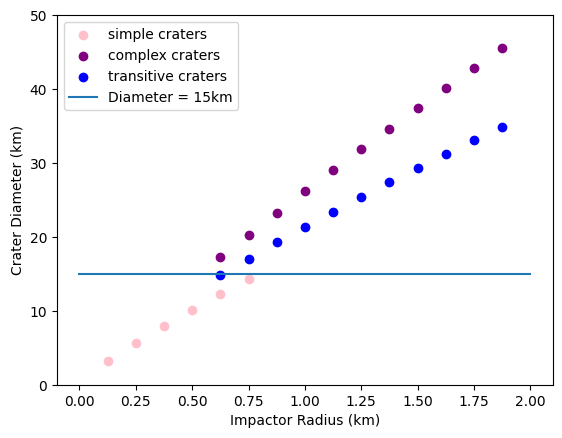

In [157]:
# data for scatter plots

# simple crater diameter
sdiams = []
sradii = []
for r in iradii:
    srad = simple_cradius(r, density, g, k, z, v)
    if srad < 7.5:
        sdiams.append(2*srad)
        sradii.append(r)

# complex crater diameter
cdiams = []
cradii = []
tdiams = []
for r in iradii:
    print(r, density, g, v, s_density, theta) 
    cdiam = complex_cdiam(r, density, g, v, s_density, theta)
    tdiam = iradius_to_tdiam(density, s_density, r, v, g, theta)
    print(cdiam)
    if cdiam > 15:
        cdiams.append(cdiam)
        cradii.append(r)
        tdiams.append(tdiam)

# create scatter plot
plt.scatter(sradii, sdiams, color="pink", label="simple craters")
plt.scatter(cradii, cdiams, color="purple", label="complex craters")
plt.scatter(cradii, tdiams, color="blue", label="transitive craters")
x = np.linspace(0, 2, 100)
y = np.linspace(15, 15, 100)
plt.plot(x, y, label="Diameter = 15km")
plt.xlabel("Impactor Radius (km)")
plt.ylabel("Crater Diameter (km)")
plt.ylim(0, 50)
plt.legend()
plt.show()

In [82]:
# calculate data to go in the csv
# crater depth function
cdepths = []
for r in iradii:
    cdepths.append(iradius_to_cdepth(r, density, g, k, z, v))

h_excs = []
for i in iradii:
    h_excs.append(iradius_to_h_exc(i, density, g, k, z, v))

# create list
data = [["impactor", "crater", "maximum excavation"]]
for i in range(len(iradii)):
    data.append([iradii[i], fcdepths[i], fh_excs[i]])

# Simulation data
sim_r = [0.125, 0.5, 2.5, 5, 10]
sim_h = [1.3, 3.25, 5.5, 8.5, 8.5]

# create csv
with open('radius_depth_hexc.csv', 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerows(data)

df = pd.read_csv('radius_depth_hexc.csv')
print(df.to_string()) 

# create linear fit for cd scatter plot
coefficientsd = np.polyfit(iradii, cdepths, 1)
f = np.poly1d(coefficientsd)
plt.plot(iradii, f(iradii), color="orchid", label="crater depth fit")

# r2 for crater depth
predicted_cd = []
for i in cdepths:
    predicted_cd.append(f(i))
cd_m, cd_b, cd_r, cd_p, cd_std_err = stats.linregress(cdepths,predicted_cd)
print(f"cd r2: {cd_r**2}")

# create linear fit for hexc scatter plot
coefficientshexc = np.polyfit(iradii, h_excs, 1)
h = np.poly1d(coefficientshexc)
plt.plot(iradii, h(iradii), color="blue", label="maximum excavation depth fit")

# r2 for max excavation depth
predicted_h_exc = []
for i in h_excs:
    predicted_h_exc.append(h(i))
h_exc_m, h_exc_b, h_exc_r, h_exc_p, h_exc_std_err = stats.linregress(h_excs,predicted_h_exc)
print(f"med r2: {h_exc_r**2}")

# create linear fit for simulation scatter plot
sim_coefficients = np.polyfit(sim_r, sim_h, 1)
j = np.poly1d(sim_coefficients)
plt.plot(sim_r, j(sim_r), color="lime", label="simulation crater depth fit")

# r2 for simulation crater depth vs self
ex_sim_self = []
for i in sim_r:
    ex_sim_self.append(j(i))
sim_m, sim_b, sim_r_val, sim_p, sim_std_err = stats.linregress(sim_h,ex_sim_self)
print(f"sim coefficients: {sim_coefficients}")
print(f"sim r2: {sim_r_val**2}")
print("expected sim self: ", end="")
for i in ex_sim_self:
    print(f"{i},", end=" ")
print("")

# r2 for simulation crater depth vs expected crater depth
ex_sim_cd = []
for i in sim_r:
    ex_sim_cd.append(f(i))
sim_cd_m, sim_cd_b, sim_cd_r, sim_cd_p, sim_cd_std_err = stats.linregress(sim_h,ex_sim_cd)
print(f"sim vs cd r2: {sim_cd_r**2}")
print("expected sim cd: ", end="")
for i in ex_sim_cd:
    print(f"{i},", end=" ")
print("")

# r2 for simulation crater depth vs expected max excavation depth
ex_sim_h_exc = []
for i in sim_r:
    ex_sim_h_exc.append(h(i))
sim_h_exc_m, sim_h_exc_b, sim_h_exc_r, sim_h_exc_p, sim_h_exc_std_err = stats.linregress(sim_h,ex_sim_h_exc)
print(f"sim vs cd r2: {sim_h_exc_r**2}")
print("expected sim hexc: ", end="")
for i in ex_sim_h_exc:
    print(f"{i},", end=" ")
print("")

# scatter plot
print(f"C.D. Fit Coefficients: {coefficientsd}\nM.E.D. Fit Coefficients: {coefficientshexc}")
plt.scatter(iradii, cdepths, color = "pink", label="crater depth (C.D.)")
plt.scatter(iradii, h_excs, color="teal", label="maximum excavation depth (M.E.D.)")
plt.scatter(sim_r, sim_h, color="green", label="simulation data crater depth (SIM)")
plt.legend(fontsize="8")
plt.suptitle("Impactor Radius vs. Crater Depth and Maximum Excavation Depth\n ")
plt.annotate(f"C.D. Fit Coefficients: {coefficientsd}\nM.E.D. Fit Coefficients: {coefficientshexc}\nSIM coefficients: {sim_coefficients}\nSIM r^2: {sim_r_val**2}", xy=(-0.5,32), fontsize="9")
plt.ylim(0, 10)
plt.xlabel("Impactor radius(km)")
plt.show()

NameError: name 'iradius_to_cdepth' is not defined